In [123]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse


import importlib
import sys
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Chebyshev')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/TCI')
sys.path.append('/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Correlation_function')
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Chebyshev")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/TCI")
sys.path.append("/home/t30/all/go56vod/Desktop/Student-Research-Job/Correlation_function")


import ED_Cs_Lsites as ED
import TCI_singlesite as TCI_single
import TCI_Lsite_accumulative_v1 as TCI_multi
import tensor_cross_interpolation as tci
import MPS 
import Chebyshev as Cheby
import peak_to_MPS as peakMPS
from convolution_as_MPO import construct_convolution_MPO
import convolution_as_MPO as mpo


importlib.reload(ED)
importlib.reload(TCI_single)
importlib.reload(TCI_multi)
importlib.reload(MPS)
importlib.reload(Cheby)
importlib.reload(peakMPS)
importlib.reload(mpo)

<module 'convolution_as_MPO' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Noisy/convolution_as_MPO.py'>

## TCI algorithm on noisy data

In [124]:
# define Hamiltonian terms
L = 11
n = 11
dt = 1e-2
models = ['J = 1, g = 2 , Ising Model Ham. = H','J =1 g = 2 Ham. = H - k*Hzz', 'J = 1 g = 0.5, Ham. = H - h * Hxx', 'J = 1 g = 0.5, Ham. = H - k*Hzz - h*Hxx']
threshold = 30
N = 2**n
D = L
g_par = 0.1


In [125]:
# Generate Hamiltonian
Hlist = [ED.gen_Ham(L = L, model = 0), ED.gen_Ham(L = L, model = 2)]

In [126]:
Cs_theo = ED.correlator(H= Hlist[0], L = L, dt = dt,  n = n)
print(Cs_theo.shape)

for i in range(Cs_theo.shape[0]):
    for k in range(Cs_theo.shape[1]):
        if Cs_theo.real[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = 1. + 1j* Cs_theo.imag[i,k]
        if Cs_theo.imag[i,k] > 1:
            print('i,k: (', i, ',', k, '), ', Cs_theo[i,k])
            Cs_theo[i,k] = Cs_theo.real[i,k] + 1j

Expectation value $\bra{\psi_0} X_{L/2} \ket{psi_0}$=  1.0462546363853858e-15
(11, 2048)
i,k: ( 5 , 0 ),  (1.0000000000000036+0j)


In [127]:
N_shots = 2**13 #8192 rough estimation by Bernhard
# clip to avoid tiny negative values from rounding
std_real = np.sqrt(np.clip(1 - Cs_theo.real**2, 0, None)) / np.sqrt(N_shots)
std_imag = np.sqrt(np.clip(1 - Cs_theo.imag**2, 0, None)) / np.sqrt(N_shots)

np.random.seed(0)  # optional
Cs_noise_real = np.random.normal(loc=0.0, scale=std_real)
Cs_noise_imag = np.random.normal(loc=0.0, scale=std_imag)

print(Cs_noise_real[0])

Cs_noise = Cs_theo + Cs_noise_real + 1j * Cs_noise_imag
print("shapes:", Cs_theo.shape, Cs_noise.shape)

[ 0.01948883  0.00442084  0.01081286 ...  0.00108669 -0.00514087
  0.01373149]
shapes: (11, 2048) (11, 2048)


In [128]:
diff_noisevstheo = Cs_theo-Cs_noise #should be difference between 2 matrices
err_max_noisevstheo = np.max(np.abs(diff_noisevstheo))/np.max(np.abs(Cs_theo))
print("Max error (noise vs theo): ", err_max_noisevstheo)
err_2_noisevstheo = np.linalg.norm(diff_noisevstheo)/np.linalg.norm(Cs_theo)
print("2-norm error (noise vs theo): ", err_2_noisevstheo)

Max error (noise vs theo):  0.05144266433827003
2-norm error (noise vs theo):  0.04675541920299569


In [129]:
# D = L #already defined above

func_vals_theo = Cs_theo.T #Cs is in the form (X,T)
func_vals_noise = Cs_noise.T

#first we define the function f(t)
# which returns the slice of func_vals along x for a specific time 
f_t_theo = lambda *t: Cs_theo.reshape((D,) + (2,) * n)[:,*t]
f_t_noise = lambda *t: Cs_noise.reshape((D,) + (2,) * n)[:,*t]

In [130]:
func_noise = TCI_multi.function(f_t_noise)
chi = 10

As, _, eval, err_2, err_max, func_interp_noise = TCI_multi.accumulative_tensor_cross_interpolation(func_noise,         # function to be interpolated
                                   func_vals_noise,    
                                   D,
                                   L=n,          # number of MPS tensors
                                   iters=chi-1)      # number of back-and-forth sweeps


err_max:  0.061070733517538875
err_2:  0.060569685342437535

repeated evaluations:  15860
unique evaluations 840
unique + repeated:  16700
total evaluations:  16700



In [131]:
err_max_theo, err_2_theo = MPS.errors(As, func_vals_theo)
print("Max error (theo vs interp): ", err_max_theo)
print("2-norm error (theo vs interp): ", err_2_theo)

Max error (theo vs interp):  0.036456782428083465
2-norm error (theo vs interp):  0.04024310919992731


In [132]:
for A in As:
    print(A.shape) 

(11, 1, 2, 10)
(10, 2, 10)
(10, 2, 10)
(10, 2, 10)
(10, 2, 10)
(10, 2, 10)
(10, 2, 10)
(10, 2, 8)
(8, 2, 4)
(4, 2, 2)
(2, 2, 1)


## Least squares optimization

In [133]:
fw_shift = mpo.binary_addition_MPO(L, l=+1, modular=False)
print("fw_shift shapes:", [w.shape for w in fw_shift])
id_ = [np.eye(2)[None, None] for _ in range(L)]
id_[0] *= -1.
Ws = mpo.add_MPO(fw_shift, id_)
Ws = [w for w in Ws]  # divide by 2 to account for the factor of 2 in the definition of the forward shift operator

fw_shift shapes: [(1, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 2, 2, 2), (2, 1, 2, 2)]


In [134]:
for w in Ws:
    print(w.shape)

(1, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 3, 2, 2)
(3, 1, 2, 2)


### Method 1.
First 'ls' method with lambda_=0, then 'gd' method with lambda_=1e3, lr=1e-6, batch_size=None. w with no prefactor

In [187]:
import least_squares as lls
importlib.reload(lls)

<module 'least_squares' from '/Users/giovanniconcheri/Desktop/ResearchJob/Student-Research-Job/Noisy/least_squares.py'>

In [195]:
from copy import deepcopy
As_mod = [deepcopy(A) for A in As]

In [196]:
ls_eng = lls.Engine(As_mod, Ws, func_noise.cache)

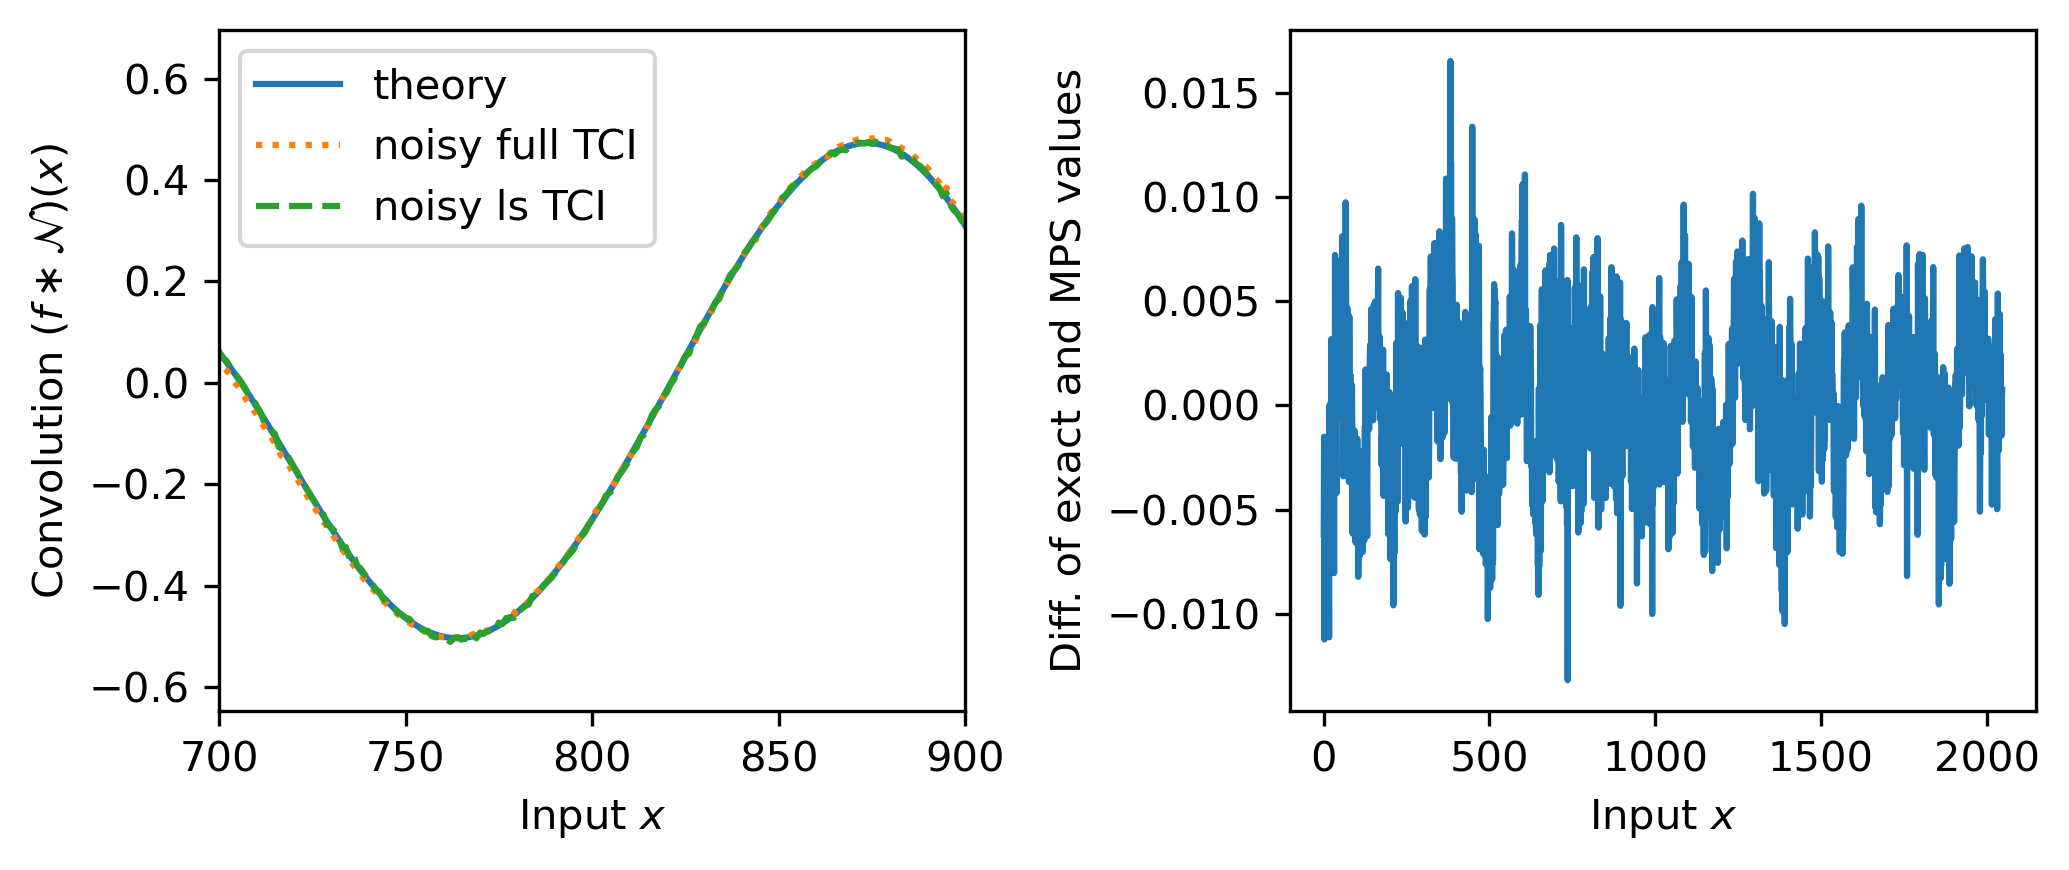

Max error w.r.t. noisy function:  0.061070733517538875 0.05288893539969368
2-norm error w.r.t. noisy function:  0.060569685342437535 0.047564295783096414

Max error w.r.t. exact function:  0.036456782428083465 0.0337857785415986
2-norm error w.r.t. exact function:  0.04024310919992731 0.01737995879258125


In [197]:
ls_eng.sweep(method='als', lambda_=0, 
                    lr = 0.1, 
                    batch_size=None) # batch_size is the number of samples to use for stochastic optimization
As_new = ls_eng.As

# Scegli l'indice spaziale/temporale da visualizzare nel plot

idx_to_plot = 1

xs = np.arange(N)

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(np.arange(N), func_vals_theo[:,0], '-', label = 'theory')
axs[0].plot(np.arange(N), func_interp_noise[:,0], ':', label = 'noisy full TCI')
axs[0].plot(np.arange(N), MPS.interpolate_func(As_new)[:,0], '--', label = 'noisy ls TCI')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].set_xlim([700,900])
# axs[0].set_ylim([-0.2, 0.2])
axs[0].legend()

axs[1].plot(xs, func_vals_theo[:,0] - MPS.interpolate_func(As_new)[:,0], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

plt.tight_layout()
plt.show()

err_max_ls_noise, err_2_ls_noise = MPS.errors(As_new, func_vals_noise)
print("Max error w.r.t. noisy function: ", err_max, err_max_ls_noise)
print("2-norm error w.r.t. noisy function: ", err_2, err_2_ls_noise)
print()
err_max_ls_theo, err_2_ls_theo = MPS.errors(As_new, func_vals_theo)
print("Max error w.r.t. exact function: ", err_max_theo, err_max_ls_theo)
print("2-norm error w.r.t. exact function: ", err_2_theo, err_2_ls_theo)


In [198]:
# ls_eng.sweep(method='als', lambda_=0, 
#                     lr = 0.01, 
#                     batch_size=None) # batch_size is the number of samples to use for stochastic optimization
# As_new = ls_eng.As

# err_max_ls_noise, err_2_ls_noise = MPS.errors(As_new, func_vals_noise)
# print("Max error w.r.t. noisy function: ", err_max, err_max_ls_noise)
# print("2-norm error w.r.t. noisy function: ", err_2, err_2_ls_noise)
# print()
# err_max_ls_theo, err_2_ls_theo = MPS.errors(As_new, func_vals_theo)
# print("Max error w.r.t. exact function: ", err_max_theo, err_max_ls_theo)
# print("2-norm error w.r.t. exact function: ", err_2_theo, err_2_ls_theo)


In [ ]:
n_iterations = 60

In [200]:
for n in range(n_iterations):
    ls_eng.sweep(method='gd', lambda_=1e3, lr = 1e-6, batch_size=None) # batch_size is the number of samples to use for stochastic optimization
    
    As_new = ls_eng.As

    if n % 5 == 0:  # Print errors every 5 iterations
        err_max_ls_theo, err_2_ls_theo = MPS.errors(As_new, func_vals_theo)
        print("Max error w.r.t. exact function: ", err_max_theo, err_max_ls_theo)
        print("2-norm error w.r.t. exact function: ", err_2_theo, err_2_ls_theo)

Max error w.r.t. exact function:  0.036456782428083465 0.03262625868981481
2-norm error w.r.t. exact function:  0.04024310919992731 0.017068635672218932
Max error w.r.t. exact function:  0.036456782428083465 0.027772443961353317
2-norm error w.r.t. exact function:  0.04024310919992731 0.01579206280465593
Max error w.r.t. exact function:  0.036456782428083465 0.024161145086055175
2-norm error w.r.t. exact function:  0.04024310919992731 0.014876810576476274
Max error w.r.t. exact function:  0.036456782428083465 0.02144686919120907
2-norm error w.r.t. exact function:  0.04024310919992731 0.014214469351871479
Max error w.r.t. exact function:  0.036456782428083465 0.019384009477445376
2-norm error w.r.t. exact function:  0.04024310919992731 0.013730279689086071
Max error w.r.t. exact function:  0.036456782428083465 0.01840027001443428
2-norm error w.r.t. exact function:  0.04024310919992731 0.013373101983803627
Max error w.r.t. exact function:  0.036456782428083465 0.019430561283558044
2-no

### Method 2.
First 'ls' method with lambda_ big, then 'ls' method with small lambda, batch_size=None. w with no prefactor

In [211]:
from copy import deepcopy
As_mod = [deepcopy(A) for A in As]

In [212]:
ls_eng = lls.Engine(As_mod, Ws, func_noise.cache)

/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/giovanniconcheri/miniconda3/envs/Computational/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


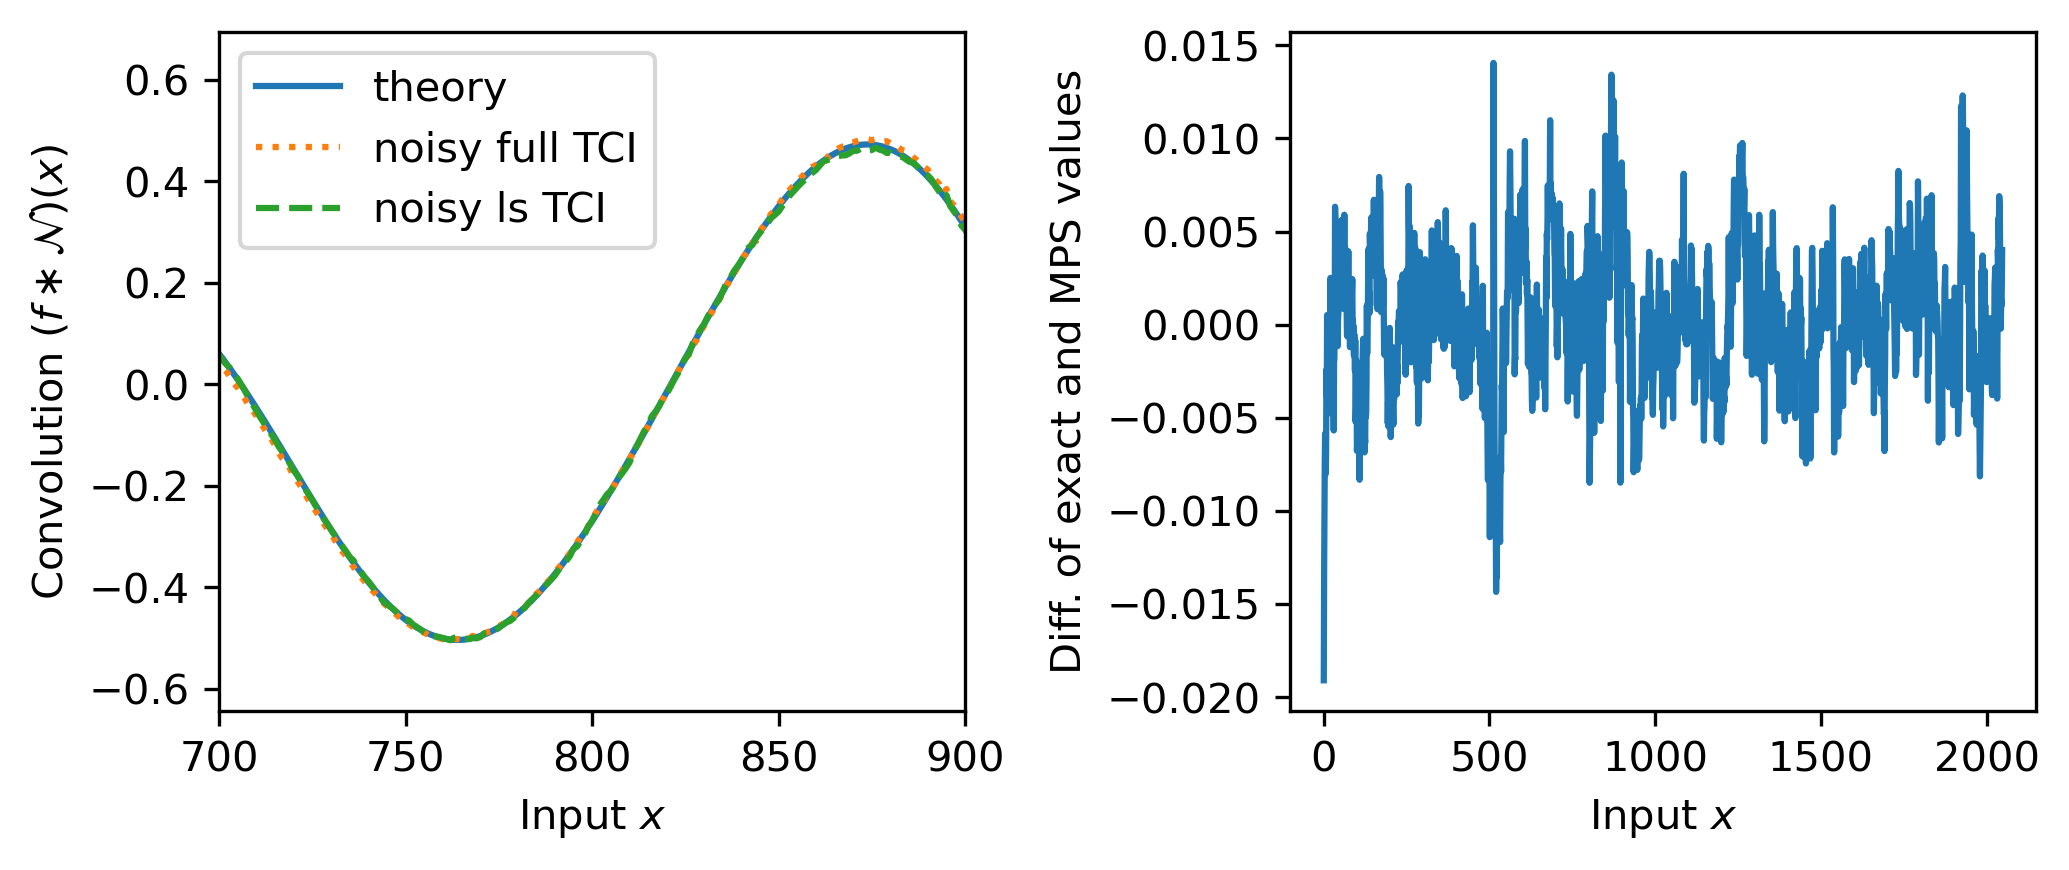

Max error w.r.t. noisy function:  0.061070733517538875 0.06475886844071724
2-norm error w.r.t. noisy function:  0.060569685342437535 0.04781060627560449

Max error w.r.t. exact function:  0.036456782428083465 0.06652303653895494
2-norm error w.r.t. exact function:  0.04024310919992731 0.01701135936416026


In [ ]:
ls_eng.sweep(method='als', lambda_=1e-4, 
                    batch_size=None) # batch_size is the number of samples to use for stochastic optimization
As_new = ls_eng.As

# Scegli l'indice spaziale/temporale da visualizzare nel plot

idx_to_plot = 1

xs = np.arange(N)

# Plot comparison
fig, axs = plt.subplots(ncols=2, figsize=(7,3), dpi=300)
axs[0].plot(np.arange(N), func_vals_theo[:,0], '-', label = 'theory')
axs[0].plot(np.arange(N), func_interp_noise[:,0], ':', label = 'noisy full TCI')
axs[0].plot(np.arange(N), MPS.interpolate_func(As_new)[:,0], '--', label = 'noisy ls TCI')
axs[0].set(xlabel=r'Input $x$',
           ylabel=r'Convolution $(f \ast \mathcal{N})(x)$')
axs[0].set_xlim([700,900])
# axs[0].set_ylim([-0.2, 0.2])
axs[0].legend()

axs[1].plot(xs, func_vals_theo[:,0] - MPS.interpolate_func(As_new)[:,0], '-')
axs[1].set(xlabel=r'Input $x$',
           ylabel='Diff. of exact and MPS values')

plt.tight_layout()
plt.show()

err_max_ls_noise, err_2_ls_noise = MPS.errors(As_new, func_vals_noise)
print("Max error w.r.t. noisy function: ", err_max, err_max_ls_noise)
print("2-norm error w.r.t. noisy function: ", err_2, err_2_ls_noise)
print()
err_max_ls_theo, err_2_ls_theo = MPS.errors(As_new, func_vals_theo)
print("Max error w.r.t. exact function: ", err_max_theo, err_max_ls_theo)
print("2-norm error w.r.t. exact function: ", err_2_theo, err_2_ls_theo)
